# Normalization analysis

Examines raw distributions for each physical variable across pressure levels to evaluate the current global z-score normalization and identify improvements (log transforms, derived features, seasonal/spatial stratification).

**Dataset**: `data/train_data/train.zarr` — 14610 daily snapshots, 4 vars × 7 levels, 64×64 grid
**Variables**: `ta` (temperature K), `hus` (specific humidity kg/kg), `ua` / `va` (wind m/s)
**Levels (hPa)**: 1000, 850, 700, 500, 250, 100, 50

In [ ]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore")

ZARR_PATH = "../data/train_data/train.zarr"
NORM_PATH = "../data/stats/normalization_no_rh_aux0.json"

# subsample fraction for heavy histogram plots (1.0 = all data)
SAMPLE_FRAC = 0.15
RNG = np.random.default_rng(42)

In [ ]:
ds = xr.open_zarr(ZARR_PATH)
ds

<xarray.Dataset> Size: 7GB
Dimensions:          (vars_aux: 8, lat: 64, lon: 64, time: 14610,
                      vars_level: 4, level: 7)
Coordinates:
  * vars_aux         (vars_aux) <U23 736B 'land_sea_mask' ... 'type_of_high_v...
  * lat              (lat) float64 512B -30.0 -28.5 -27.0 ... 61.5 63.0 64.5
  * lon              (lon) float64 512B 300.0 301.5 303.0 ... 31.5 33.0 34.5
  * time             (time) datetime64[ns] 117kB 1979-01-01 ... 2018-12-31
  * vars_level       (vars_level) <U3 48B 'ta' 'hus' 'ua' 'va'
  * level            (level) int64 56B 1000 850 700 500 250 100 50
Data variables:
    input_auxiliary  (vars_aux, lat, lon) float32 131kB dask.array<chunksize=(8, 64, 64), meta=np.ndarray>
    input_level      (time, vars_level, level, lat, lon) float32 7GB dask.array<chunksize=(1, 4, 7, 64, 64), meta=np.ndarray>
    target           (time, lat, lon) float32 239MB dask.array<chunksize=(1, 64, 64), meta=np.ndarray>

In [ ]:
with open(NORM_PATH) as f:
    norm = json.load(f)

LEVELS = np.array(norm["levels"])  # hPa
LEVELS_PA = np.array(norm["pressure_levels_pa"])  # Pa
VARS = norm["vars_level"]  # ['ta','hus','ua','va']
N_LEVELS = len(LEVELS)

# reshape stored stats into (var, level) arrays
norm_mean = np.array(norm["mean"]).reshape(len(VARS), N_LEVELS)
norm_std = np.array(norm["std"]).reshape(len(VARS), N_LEVELS)

print(f"Levels (hPa): {LEVELS.astype(int).tolist()}")
print(f"Vars:         {VARS}")
print("\nNorm mean per (var, level):")
for i, v in enumerate(VARS):
    print(f"  {v}: {norm_mean[i].round(4).tolist()}")

Levels (hPa): [1000, 850, 700, 500, 250, 100, 50]
Vars:         ['ta', 'hus', 'ua', 'va']

Norm mean per (var, level):
  ta: [294.5314, 287.0106, 278.5075, 262.8052, 227.5807, 201.3645, 209.7195]
  hus: [0.0107, 0.0069, 0.0038, 0.0012, 0.0001, 0.0, 0.0]
  ua: [-1.4121, -0.9149, 0.4313, 3.5049, 11.6992, 6.7588, -1.2148]
  va: [0.1674, -0.1054, -0.1721, -0.0226, 0.0308, 0.281, -0.0946]


In [ ]:
# Draw a random time subset for plotting (keeps memory manageable)
n_time = ds.sizes["time"]
n_sample = max(1, int(n_time * SAMPLE_FRAC))
t_idx = np.sort(RNG.choice(n_time, size=n_sample, replace=False))
print(f"Using {n_sample}/{n_time} time steps for distribution plots")

# Load sampled block: (n_sample, 4, 7, 64, 64)
il = ds["input_level"].isel(time=t_idx).values
print(f"input_level shape: {il.shape}  dtype: {il.dtype}")

Using 2191/14610 time steps for distribution plots
input_level shape: (2191, 4, 7, 64, 64)  dtype: float32


## 1 — Summary statistics table
Mean, std, skewness, excess kurtosis for every (var, level) in raw physical units.

In [ ]:
import pandas as pd

rows = []
var_names_long = {
    "ta": "temp (K)",
    "hus": "spec_hum (kg/kg)",
    "ua": "u-wind (m/s)",
    "va": "v-wind (m/s)",
}
for vi, vname in enumerate(VARS):
    for li, lev in enumerate(LEVELS):
        vals = il[:, vi, li, :, :].ravel()
        rows.append(
            {
                "var": vname,
                "level_hPa": int(lev),
                "mean": vals.mean(),
                "std": vals.std(),
                "skew": float(scipy_stats.skew(vals)),
                "excess_kurt": float(scipy_stats.kurtosis(vals)),
                "min": vals.min(),
                "max": vals.max(),
            }
        )

df = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.4g}".format)
df

,var,level_hPa,mean,std,skew,excess_kurt,min,max
0,ta,1000,293.1,9.155,-0.7675,0.7625,240.1,319.3
1,ta,850,285.7,8.822,-0.9353,0.6294,234.2,307.7
2,ta,700,277.3,7.717,-1.428,1.595,226.9,291.7
3,ta,500,261.6,7.705,-1.375,1.331,221.2,275.9
4,ta,250,226.8,5.482,-0.8942,-0.03569,200.6,241.8
5,ta,100,203.1,9.864,0.6041,-0.792,183.8,237.6
6,ta,50,210.4,5.325,0.7077,0.6126,186.7,241.3
7,hus,1000,0.01008,0.004786,-0.03207,-1.239,5.213e-05,0.02095
8,hus,850,0.006514,0.003743,0.4151,-0.9585,1.093e-05,0.01623
9,hus,700,0.003545,0.002494,0.5055,-0.9602,9.416e-06,0.01139


## 2 — Raw distributions per variable
Histograms at each pressure level. The dashed vertical line shows the global mean used for current normalization.

In [ ]:
COLORS = plt.cm.plasma_r(np.linspace(0.1, 0.9, N_LEVELS))
LEVEL_LABELS = [f"{int(_level)} hPa" for _level in LEVELS]


def plot_distributions(
    data, var_idx, title, xlabel, norm_means=None, log_x=False, n_bins=80, xlim=None
):
    fig, axes = plt.subplots(1, N_LEVELS, figsize=(18, 3), sharey=False)
    fig.suptitle(title, fontsize=13, y=1.01)
    for li, (ax, color, label) in enumerate(zip(axes, COLORS, LEVEL_LABELS)):
        vals = data[:, var_idx, li, :, :].ravel()
        if log_x:
            vals = np.log(vals + 1e-12)
        ax.hist(vals, bins=n_bins, color=color, alpha=0.85, density=True)
        if norm_means is not None:
            m = norm_means[var_idx, li]
            if log_x:
                m = np.log(m + 1e-12)
            ax.axvline(m, color="black", lw=1.5, ls="--", label="norm mean")
        ax.set_title(label, fontsize=9)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.tick_params(labelsize=7)
        if xlim:
            ax.set_xlim(xlim)
        # skew annotation
        sk = float(scipy_stats.skew(vals))
        ax.text(
            0.97,
            0.95,
            f"skew={sk:.2f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=7,
        )
    axes[0].set_ylabel("density", fontsize=8)
    plt.tight_layout()
    plt.show()

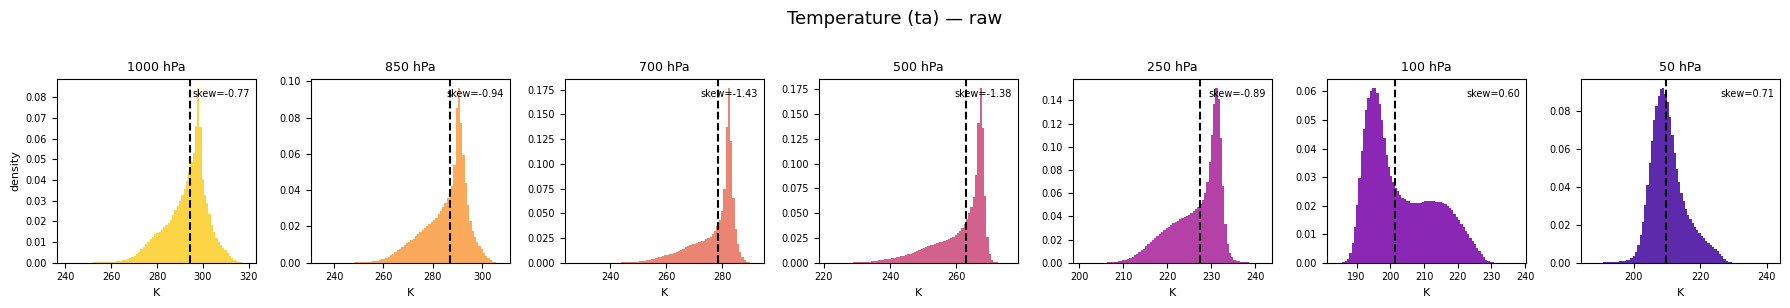

In [ ]:
plot_distributions(il, 0, "Temperature (ta) — raw", "K", norm_mean)

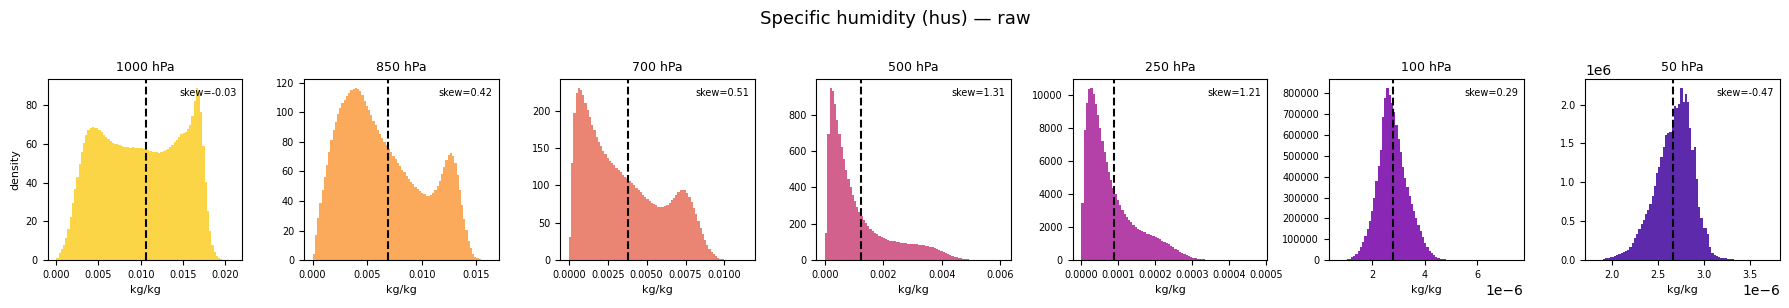

In [ ]:
plot_distributions(il, 1, "Specific humidity (hus) — raw", "kg/kg", norm_mean)

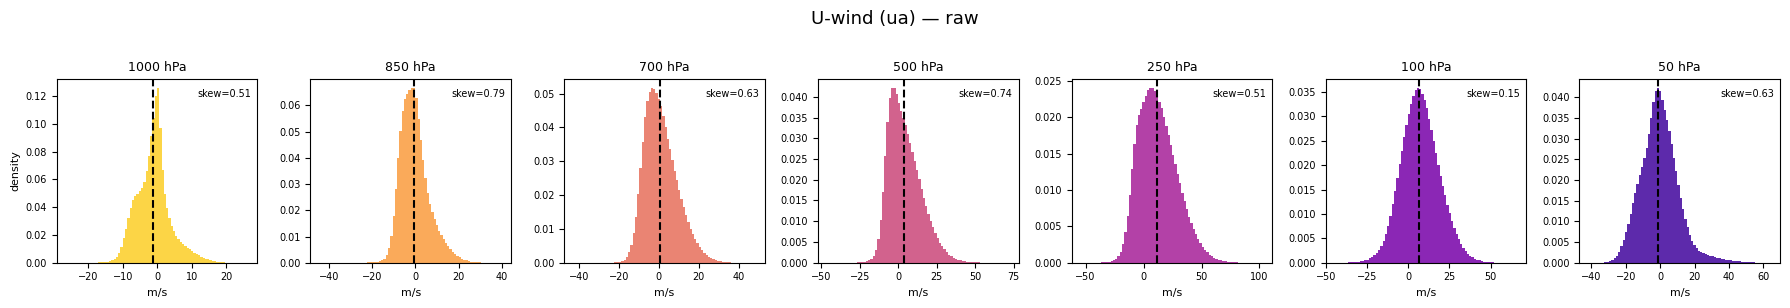

In [ ]:
plot_distributions(il, 2, "U-wind (ua) — raw", "m/s", norm_mean)

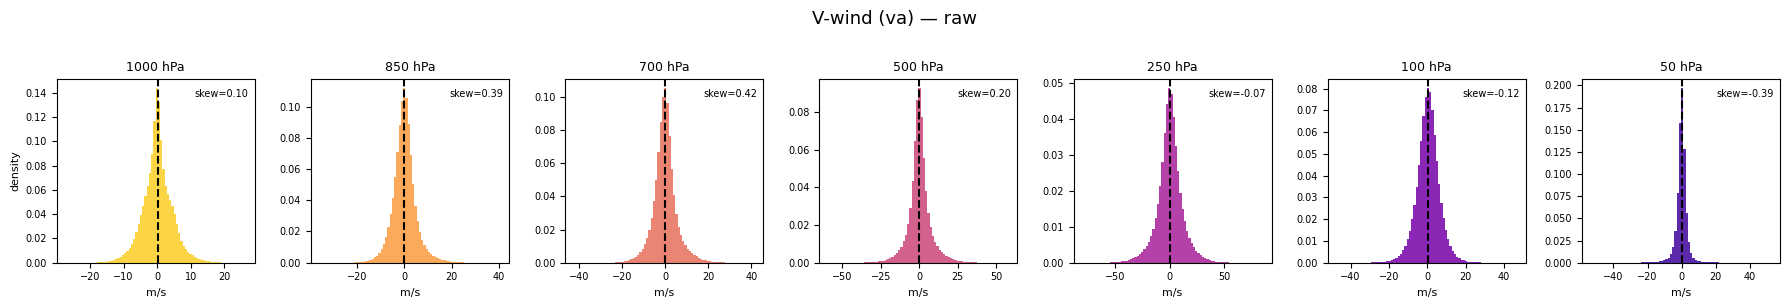

In [ ]:
plot_distributions(il, 3, "V-wind (va) — raw", "m/s", norm_mean)

## 3 — Log-transform for specific humidity
`hus` spans ~3 orders of magnitude across levels (very right-skewed). `log(hus)` should be approximately Gaussian, making z-scoring much more representative.

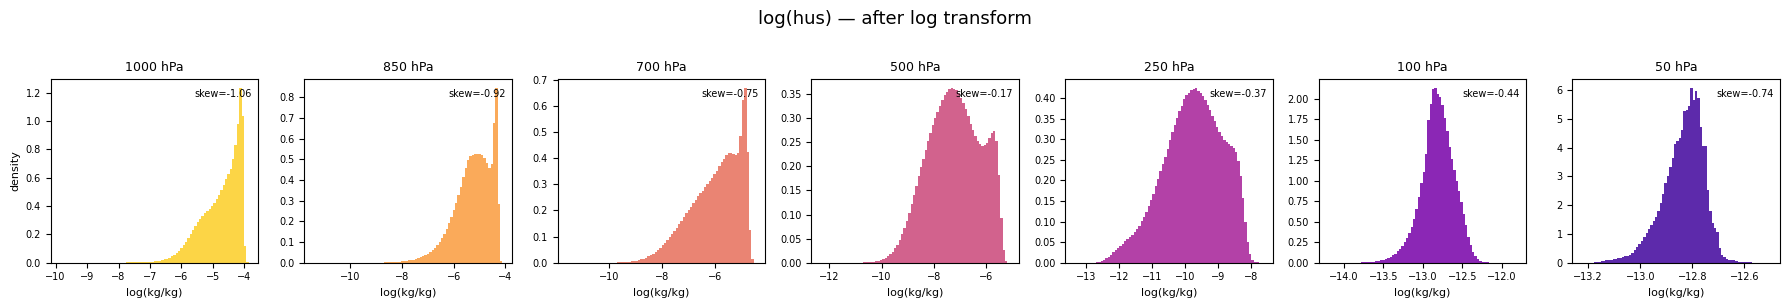

In [ ]:
plot_distributions(il, 1, "log(hus) — after log transform", "log(kg/kg)", log_x=True)

In [ ]:
# Quantify skewness improvement
print(f"{'Level':>10} {'raw skew':>12} {'log skew':>12} {'improvement':>12}")
print("-" * 50)
for li, lev in enumerate(LEVELS):
    vals = il[:, 1, li, :, :].ravel()
    raw_sk = float(scipy_stats.skew(vals))
    log_sk = float(scipy_stats.skew(np.log(vals + 1e-12)))
    print(
        f"{int(lev):>7} hPa {raw_sk:>12.3f} {log_sk:>12.3f} "
        f"{abs(raw_sk) - abs(log_sk):>12.3f}"
    )

     Level     raw skew     log skew  improvement
--------------------------------------------------
   1000 hPa       -0.032       -1.056       -1.024
    850 hPa        0.415       -0.921       -0.506
    700 hPa        0.506       -0.748       -0.243
    500 hPa        1.310       -0.173        1.137
    250 hPa        1.214       -0.368        0.846
    100 hPa        0.292       -0.438       -0.146
     50 hPa       -0.474       -0.744       -0.270


## 4 — Normalized distributions (current z-score)
After applying the current global mean/std. A good normalization should give ~N(0,1) at each level.

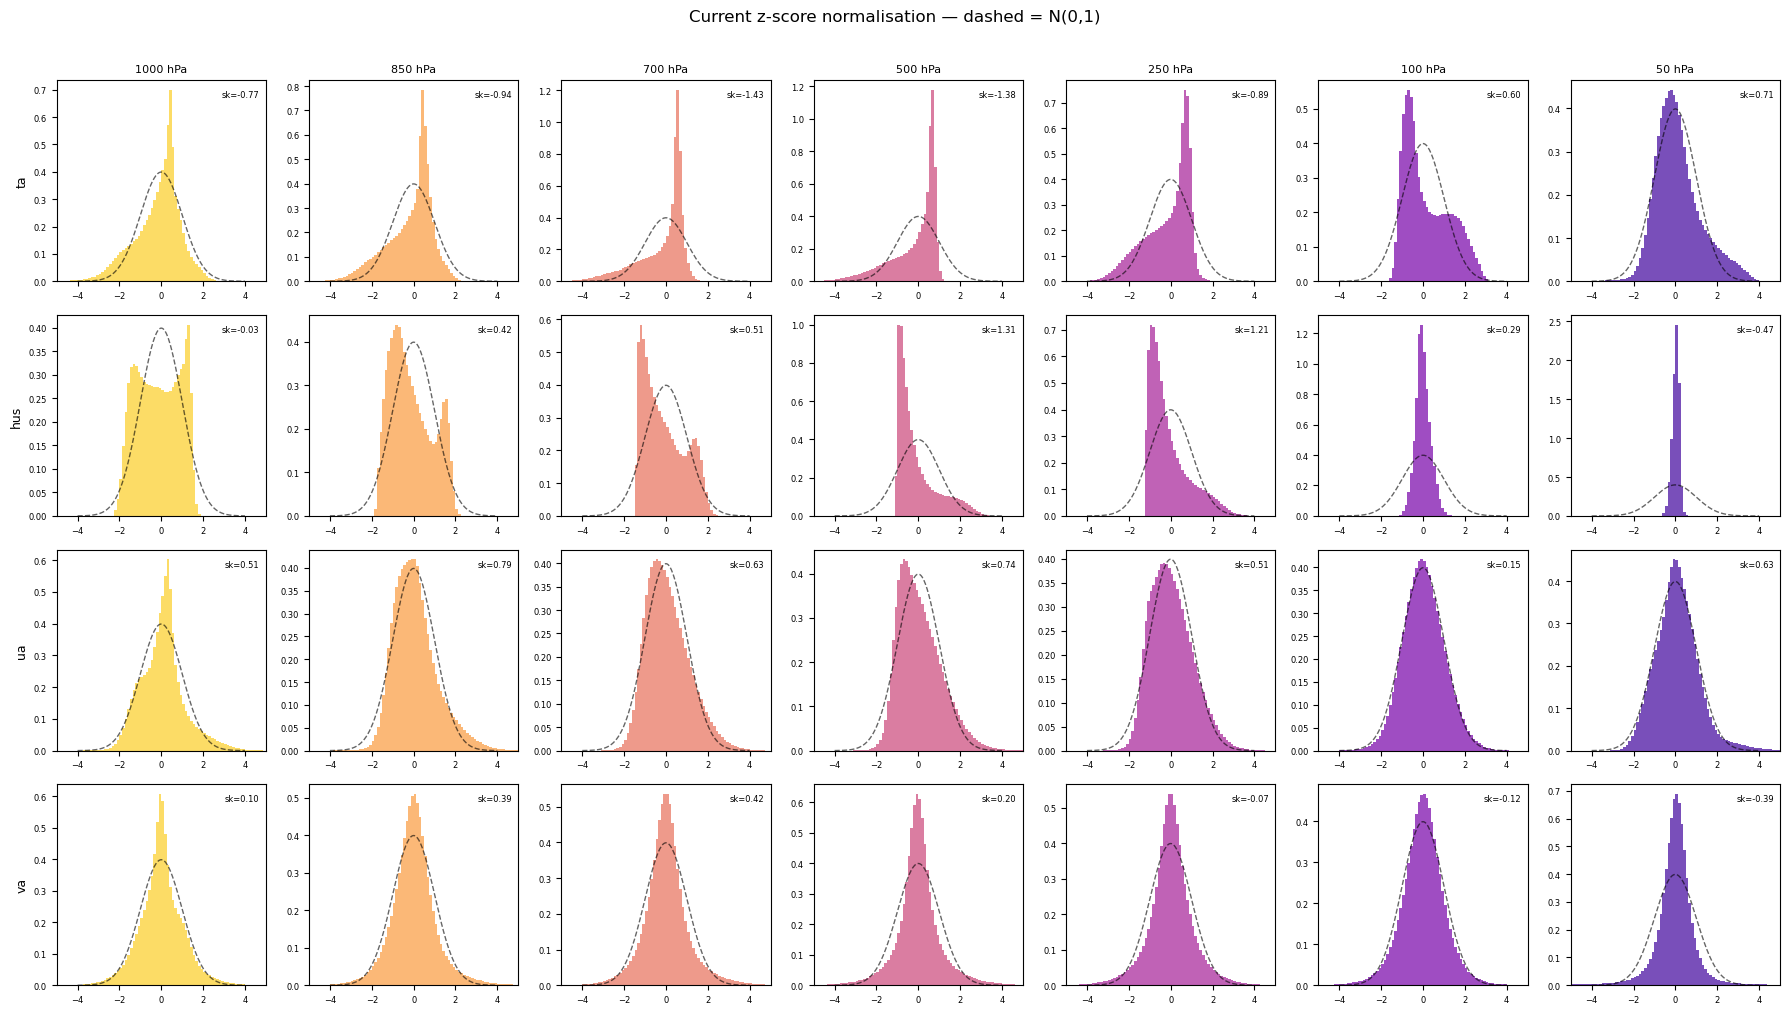

In [ ]:
fig, axes = plt.subplots(len(VARS), N_LEVELS, figsize=(18, 10), sharey=False)
x_ref = np.linspace(-4, 4, 200)
gauss = scipy_stats.norm.pdf(x_ref)

for vi, vname in enumerate(VARS):
    for li, lev in enumerate(LEVELS):
        ax = axes[vi, li]
        vals = il[:, vi, li, :, :].ravel()
        z = (vals - norm_mean[vi, li]) / (norm_std[vi, li] + 1e-6)
        ax.hist(z, bins=80, density=True, color=COLORS[li], alpha=0.7, range=(-5, 5))
        ax.plot(x_ref, gauss, "k--", lw=1, alpha=0.6)
        ax.set_xlim(-5, 5)
        ax.tick_params(labelsize=6)
        if vi == 0:
            ax.set_title(f"{int(lev)} hPa", fontsize=8)
        if li == 0:
            ax.set_ylabel(vname, fontsize=9)
        sk = float(scipy_stats.skew(z))
        ax.text(
            0.97,
            0.95,
            f"sk={sk:.2f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=6,
        )

fig.suptitle("Current z-score normalisation — dashed = N(0,1)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 5 — Relative humidity distribution (derived)
RH per level computed from raw `ta`, `hus`, and pressure. Compare actual mean/std vs the fixed normalization used in `geounet_wide_rh` (`(rh - 0.5) * 4.0`).

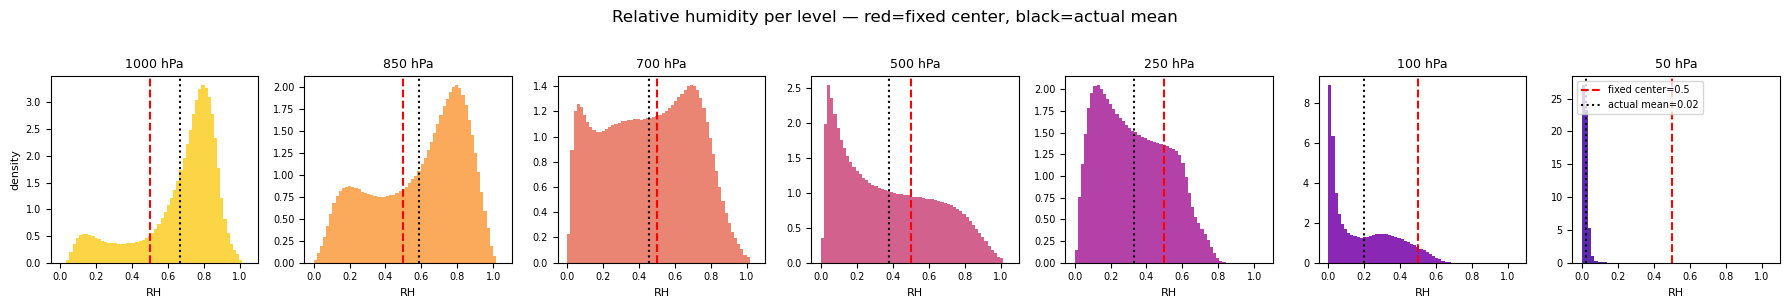


RH stats per level:
     Level     mean      std    fixed_err
   1000 hPa    0.667    0.218        0.167
    850 hPa    0.588    0.251        0.088
    700 hPa    0.455    0.249       -0.045
    500 hPa    0.377    0.264       -0.123
    250 hPa    0.330    0.190       -0.170
    100 hPa    0.197    0.174       -0.303
     50 hPa    0.021    0.016       -0.479


In [ ]:
# Magnus formula constants (matching starter_kit.baselines.utils)
_RD, _RV = 287.0597, 461.51
_EPS = _RD / _RV
_A1_W, _A3_W, _A4_W = 611.21, 17.502, 32.19
_A1_I, _A3_I, _A4_I = 611.21, 22.587, -0.7
_T0, _TICE = 273.16, 250.16


def _rh_np(ta, hus, p_pa):
    sat_w = _A1_W * np.exp(_A3_W * (ta - _T0) / (ta - _A4_W))
    sat_i = _A1_I * np.exp(_A3_I * (ta - _T0) / (ta - _A4_I))
    alpha = np.clip(((ta - _TICE) / (_T0 - _TICE)) ** 2, 0.0, 1.0)
    sat = alpha * sat_w + (1.0 - alpha) * sat_i
    vap = (hus * p_pa) / (_EPS + hus * (1.0 - _EPS))
    return np.clip(vap / (sat + 1e-12), 0.0, 1.0)


rh_all = np.stack(
    [_rh_np(il[:, 0, li], il[:, 1, li], LEVELS_PA[li]) for li in range(N_LEVELS)],
    axis=1,
)  # (n_sample, 7, 64, 64)

fig, axes = plt.subplots(1, N_LEVELS, figsize=(18, 3))
rh_means, rh_stds = [], []
for li, (ax, color, label) in enumerate(zip(axes, COLORS, LEVEL_LABELS)):
    vals = rh_all[:, li].ravel()
    rh_means.append(vals.mean())
    rh_stds.append(vals.std())
    ax.hist(vals, bins=60, color=color, alpha=0.85, density=True, range=(0, 1.05))
    ax.axvline(0.5, color="red", lw=1.5, ls="--", label="fixed center=0.5")
    ax.axvline(
        vals.mean(),
        color="black",
        lw=1.5,
        ls=":",
        label=f"actual mean={vals.mean():.2f}",
    )
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("RH", fontsize=8)
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("density", fontsize=8)
axes[-1].legend(fontsize=7, loc="upper left")
fig.suptitle(
    "Relative humidity per level — red=fixed center, black=actual mean",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()

print("\nRH stats per level:")
print(f"{'Level':>10} {'mean':>8} {'std':>8} {'fixed_err':>12}")
for li, lev in enumerate(LEVELS):
    print(
        f"{int(lev):>7} hPa {rh_means[li]:>8.3f} {rh_stds[li]:>8.3f} "
        f"{rh_means[li] - 0.5:>12.3f}"
    )

## 6 — Potential temperature (θ) distribution
θ = T × (P₀/P)^0.2854. Check whether the fixed normalization `(θ − 300) / 20` is reasonable.

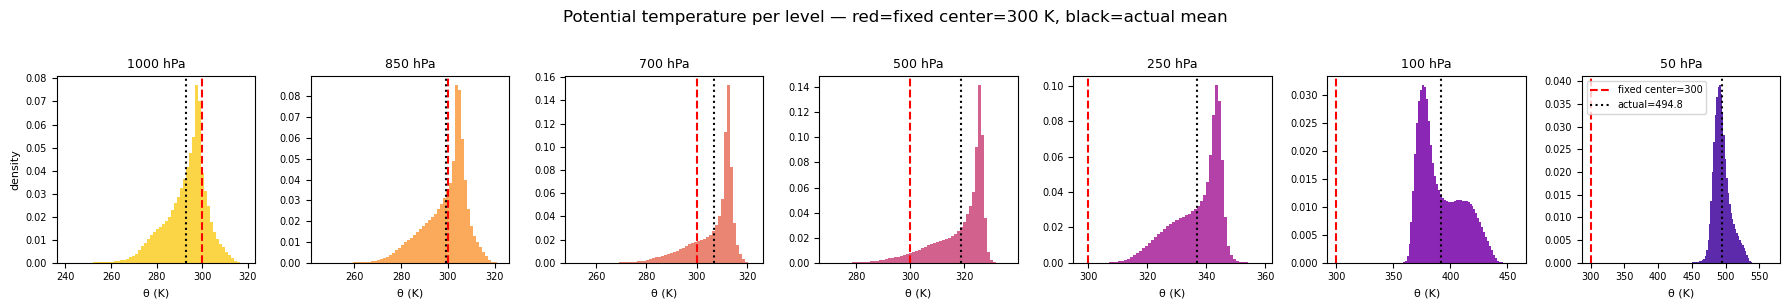


θ stats per level:
     Level     mean      std    fixed_err
   1000 hPa    293.1     9.15         -6.9
    850 hPa    299.2     9.24         -0.8
    700 hPa    307.0     8.54          7.0
    500 hPa    318.8     9.39         18.8
    250 hPa    336.9     8.14         36.9
    100 hPa    391.9    19.03         91.9
     50 hPa    494.8    12.52        194.8


In [ ]:
theta_all = np.stack(
    [il[:, 0, li] * (100000.0 / LEVELS_PA[li]) ** 0.2854 for li in range(N_LEVELS)],
    axis=1,
)  # (n_sample, 7, 64, 64)

fig, axes = plt.subplots(1, N_LEVELS, figsize=(18, 3))
theta_means, theta_stds = [], []
for li, (ax, color, label) in enumerate(zip(axes, COLORS, LEVEL_LABELS)):
    vals = theta_all[:, li].ravel()
    theta_means.append(vals.mean())
    theta_stds.append(vals.std())
    ax.hist(vals, bins=60, color=color, alpha=0.85, density=True)
    ax.axvline(300.0, color="red", lw=1.5, ls="--", label="fixed center=300")
    ax.axvline(
        vals.mean(), color="black", lw=1.5, ls=":", label=f"actual={vals.mean():.1f}"
    )
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("θ (K)", fontsize=8)
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("density", fontsize=8)
axes[-1].legend(fontsize=7)
fig.suptitle(
    "Potential temperature per level — red=fixed center=300 K, black=actual mean",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()

print("\nθ stats per level:")
print(f"{'Level':>10} {'mean':>8} {'std':>8} {'fixed_err':>12}")
for li, lev in enumerate(LEVELS):
    print(
        f"{int(lev):>7} hPa {theta_means[li]:>8.1f} {theta_stds[li]:>8.2f} "
        f"{theta_means[li] - 300.0:>12.1f}"
    )

## 7 — Seasonal cycle of variable means
Evaluates whether seasonal normalization would remove useful signal or just reduce input variance.

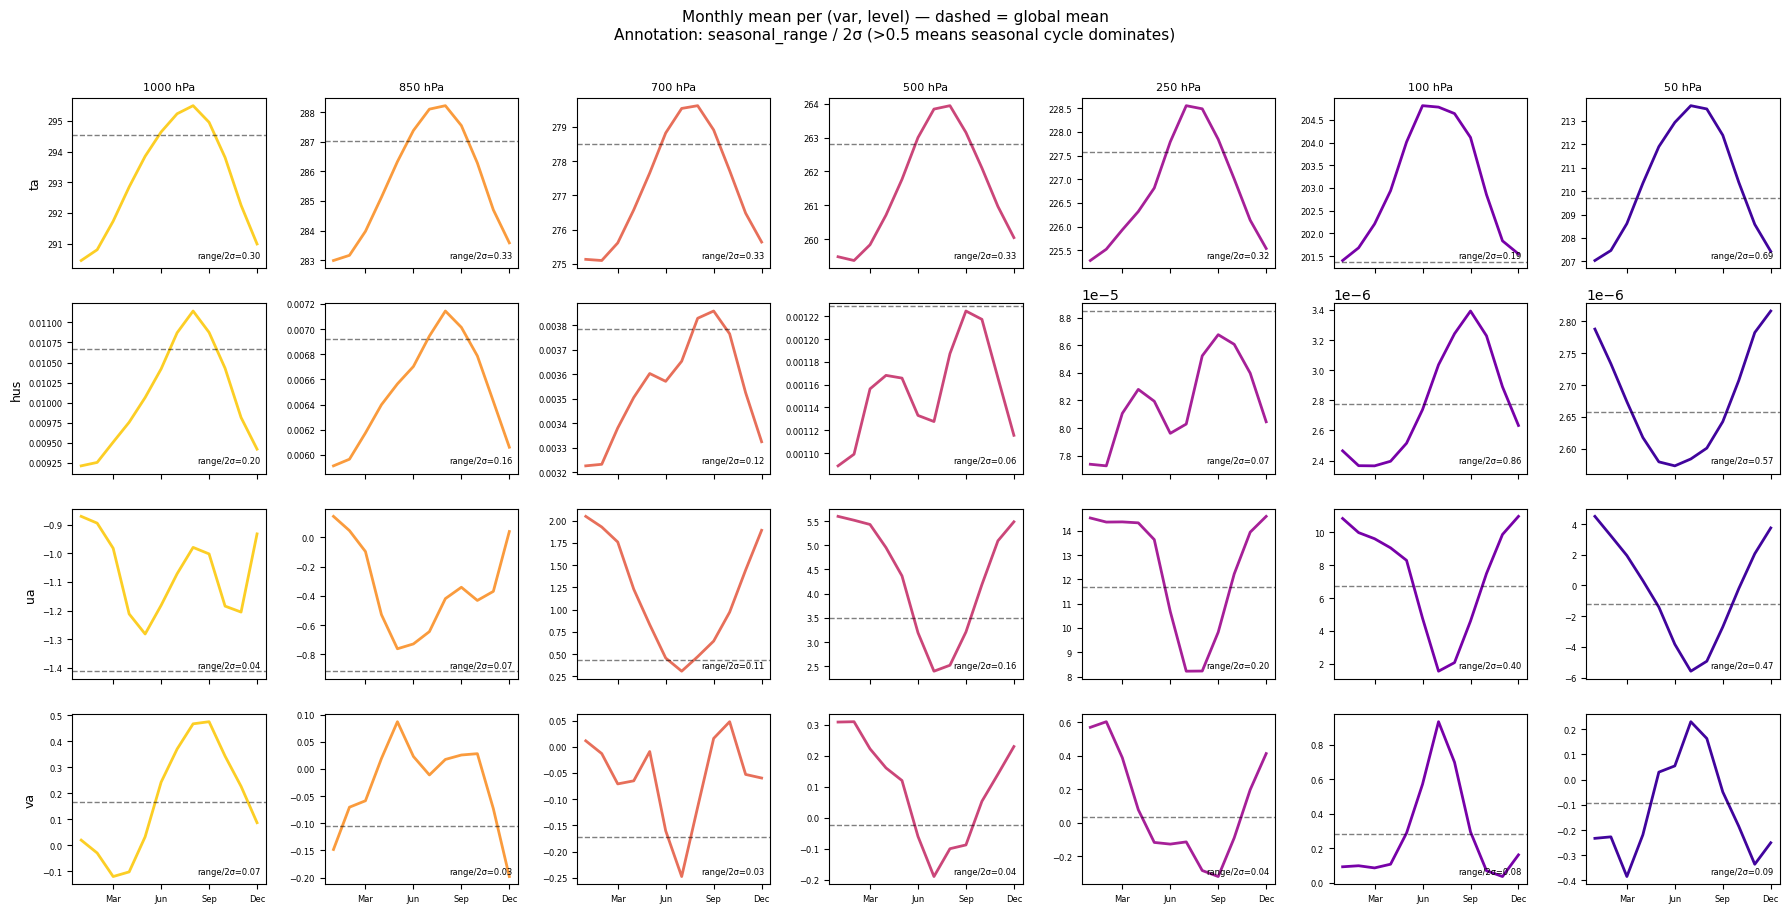

In [ ]:
# Load monthly means using xarray over full time axis (lightweight — just means)
monthly_mean = (
    ds["input_level"].mean(dim=["lat", "lon"]).groupby("time.month").mean().compute()
)  # (12, 4, 7)

fig, axes = plt.subplots(len(VARS), N_LEVELS, figsize=(18, 9), sharex=True)
months = np.arange(1, 13)
for vi, vname in enumerate(VARS):
    for li, lev in enumerate(LEVELS):
        ax = axes[vi, li]
        vals = monthly_mean.sel(vars_level=vname).isel(level=li).values
        seasonal_range = vals.max() - vals.min()
        global_std = norm_std[vi, li]
        ax.plot(months, vals, color=COLORS[li], lw=2)
        ax.axhline(norm_mean[vi, li], color="k", lw=1, ls="--", alpha=0.5)
        ax.tick_params(labelsize=6)
        if vi == 0:
            ax.set_title(f"{int(lev)} hPa", fontsize=8)
        if li == 0:
            ax.set_ylabel(vname, fontsize=9)
        # fraction of global std explained by seasonal cycle
        frac = seasonal_range / (2 * global_std + 1e-8)
        ax.text(
            0.97,
            0.05,
            f"range/{2:.0f}σ={frac:.2f}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=6,
        )
        ax.set_xticks([3, 6, 9, 12])
        ax.set_xticklabels(["Mar", "Jun", "Sep", "Dec"], fontsize=6)

fig.suptitle(
    "Monthly mean per (var, level) — dashed = global mean\nAnnotation: seasonal_range /"
    " 2σ (>0.5 means seasonal cycle dominates)",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.show()

## 8 — Spatial variation of mean and std
Evaluates whether spatially-varying normalization (climatological anomalies) would be worth the added complexity.

In [ ]:
import cartopy.crs as ccrs

# Spatial mean and std over time (full dataset, lightweight — dask)
spatial_mean = ds["input_level"].mean(dim="time").compute()  # (4, 7, 64, 64)
spatial_std = ds["input_level"].std(dim="time").compute()  # (4, 7, 64, 64)

lats = ds.lat.values
lons = ds.lon.values

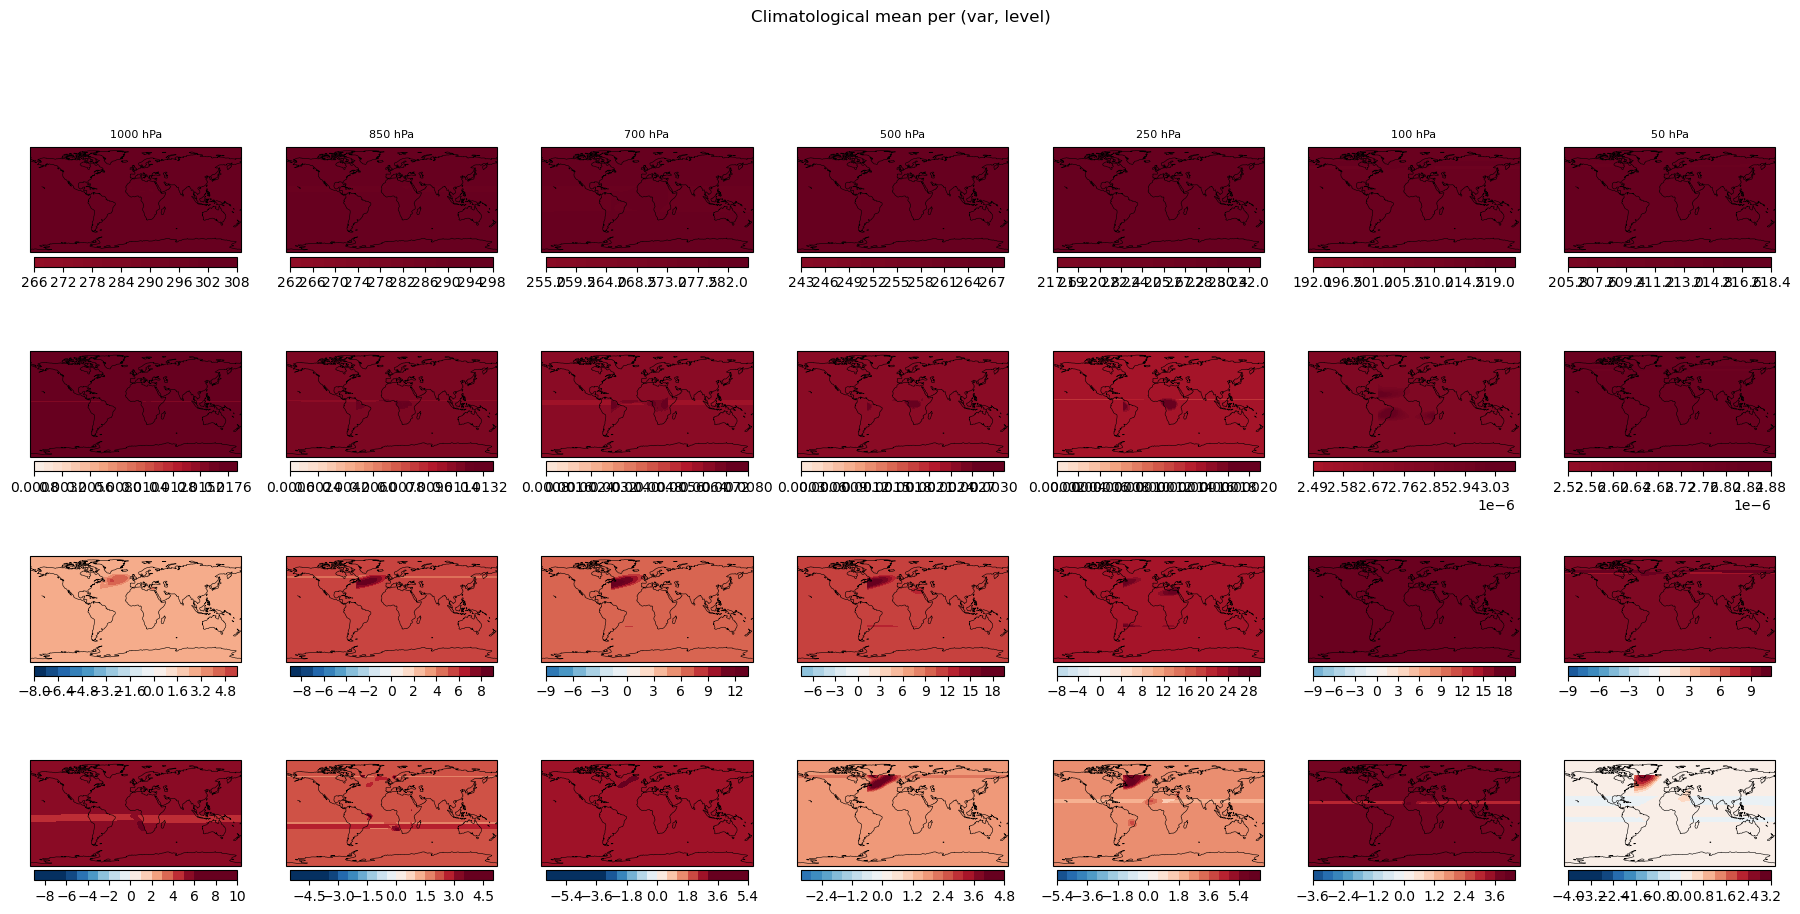

In [ ]:
def plot_spatial(da, title, cmap="RdBu_r", levels=20):
    """Plot a (4, 7, lat, lon) DataArray as a (var, level) grid of maps."""
    fig, axes = plt.subplots(
        len(VARS),
        N_LEVELS,
        figsize=(18, 9),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    for vi, vname in enumerate(VARS):
        for li, lev in enumerate(LEVELS):
            ax = axes[vi, li]
            field = da.sel(vars_level=vname).isel(level=li).values
            vabs = np.percentile(np.abs(field), 98)
            im = ax.contourf(
                lons,
                lats,
                field,
                levels=levels,
                cmap=cmap,
                vmin=-vabs,
                vmax=vabs,
                transform=ccrs.PlateCarree(),
            )
            ax.coastlines(linewidth=0.4)
            ax.tick_params(labelsize=5)
            if vi == 0:
                ax.set_title(f"{int(lev)} hPa", fontsize=8)
            if li == 0:
                ax.set_ylabel(vname, fontsize=9)
            plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.02, fraction=0.05)
    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


plot_spatial(spatial_mean, "Climatological mean per (var, level)")

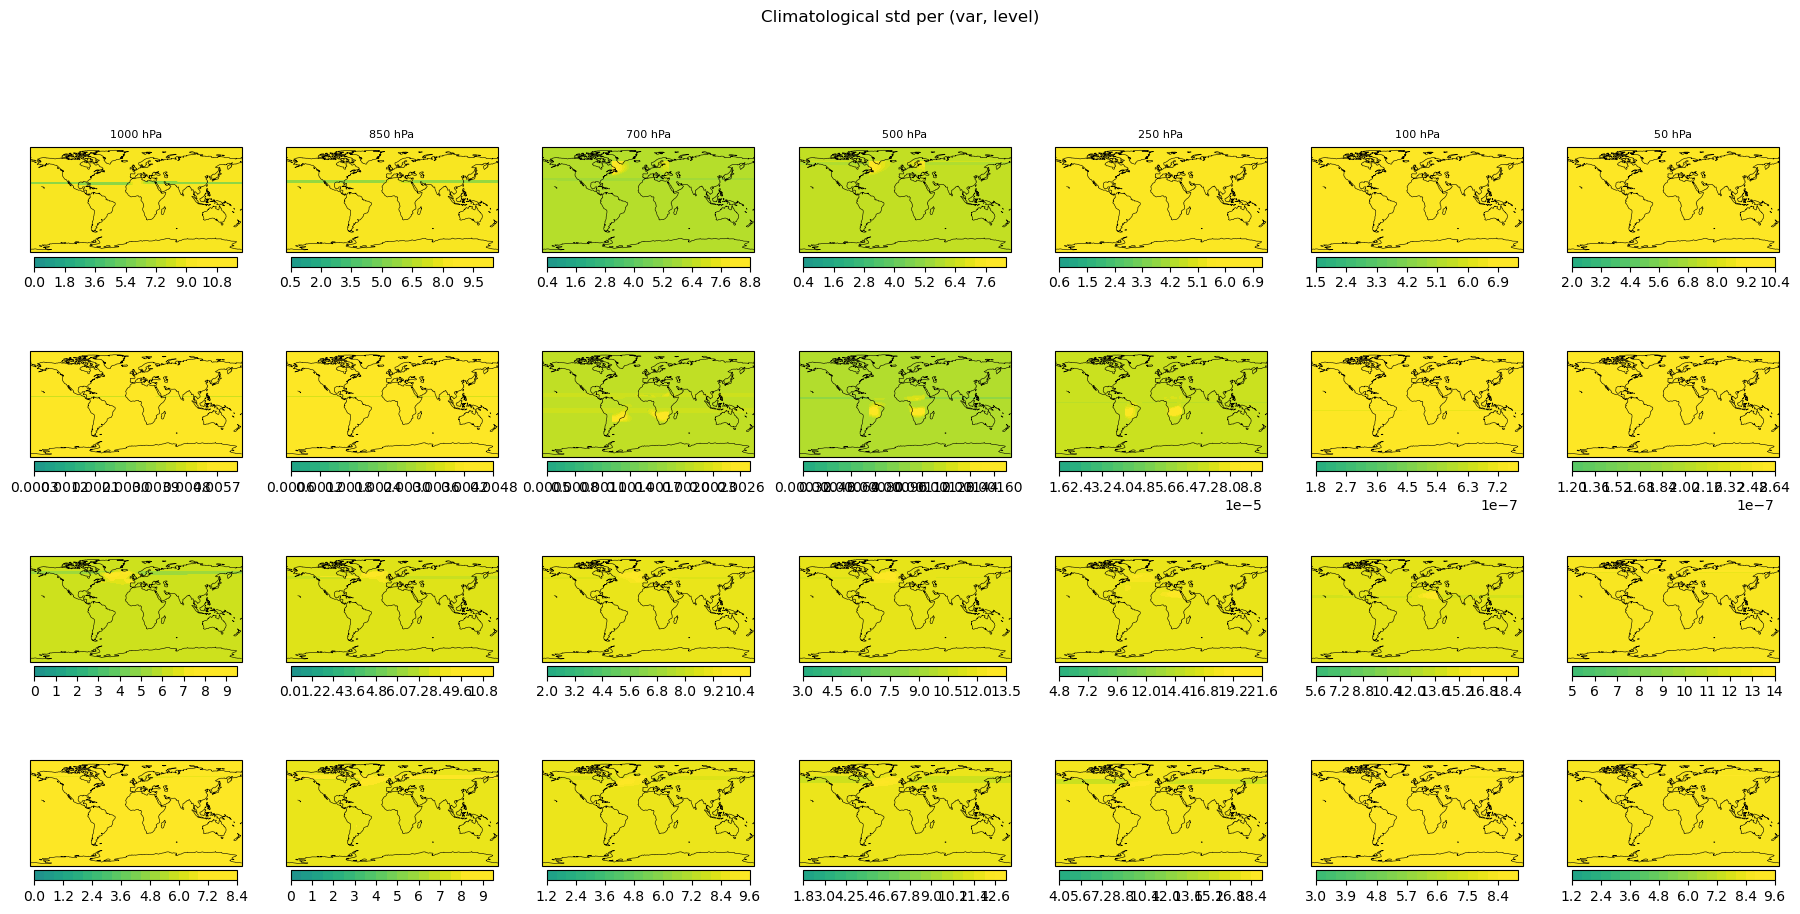

In [ ]:
plot_spatial(spatial_std, "Climatological std per (var, level)", cmap="viridis")

In [ ]:
# Ratio: spatial_std / global_std — how much of global variance is spatially structured
print("Spatial std / global std (how much local variance differs from global):")
print(f"{'':>6} " + "  ".join(f"{int(_level):>6}hPa" for _level in LEVELS))
for vi, vname in enumerate(VARS):
    ratios = []
    for li in range(N_LEVELS):
        sp_std = float(spatial_std.sel(vars_level=vname).isel(level=li).mean())
        ratios.append(sp_std / (norm_std[vi, li] + 1e-8))
    print(f"{vname:>6} " + "  ".join(f"{r:>8.3f}" for r in ratios))

Spatial std / global std (how much local variance differs from global):
         1000hPa     850hPa     700hPa     500hPa     250hPa     100hPa      50hPa
    ta    0.439     0.511     0.487     0.476     0.546     0.367     0.740
   hus    0.493     0.579     0.628     0.700     0.671     0.879     0.818
    ua    0.683     0.767     0.754     0.779     0.829     0.811     0.880
    va    0.754     0.917     0.950     0.951     0.969     0.965     0.932


## 9 — Wind speed and vertical shear distributions
Wind speed shows an asymmetric (Rayleigh-like) distribution. Shear magnitude is always positive and right-skewed.

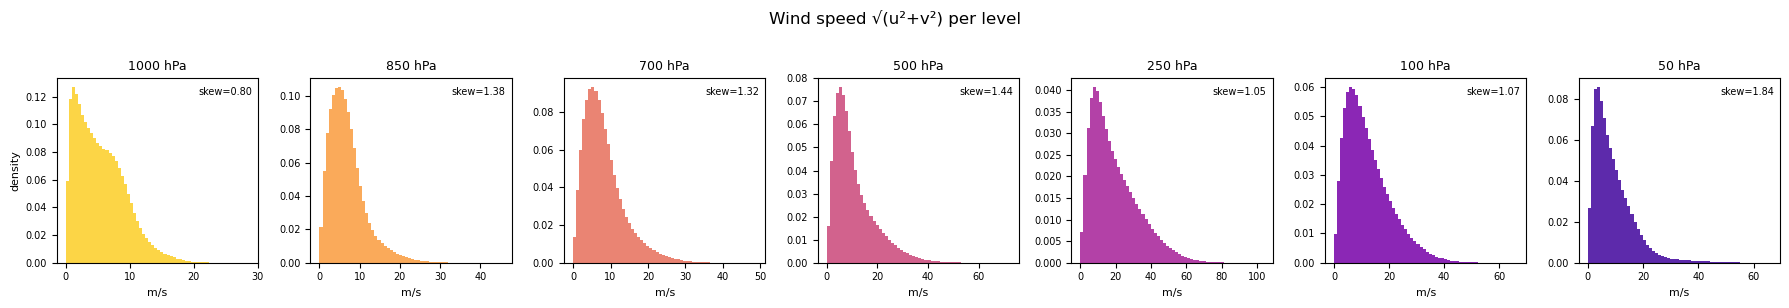

In [ ]:
wspd = np.sqrt(il[:, 2] ** 2 + il[:, 3] ** 2)  # (n_sample, 7, 64, 64)

fig, axes = plt.subplots(1, N_LEVELS, figsize=(18, 3))
for li, (ax, color, label) in enumerate(zip(axes, COLORS, LEVEL_LABELS)):
    vals = wspd[:, li].ravel()
    ax.hist(vals, bins=60, color=color, alpha=0.85, density=True)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("m/s", fontsize=8)
    ax.tick_params(labelsize=7)
    sk = float(scipy_stats.skew(vals))
    ax.text(
        0.97,
        0.95,
        f"skew={sk:.2f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=7,
    )
axes[0].set_ylabel("density", fontsize=8)
fig.suptitle("Wind speed √(u²+v²) per level", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

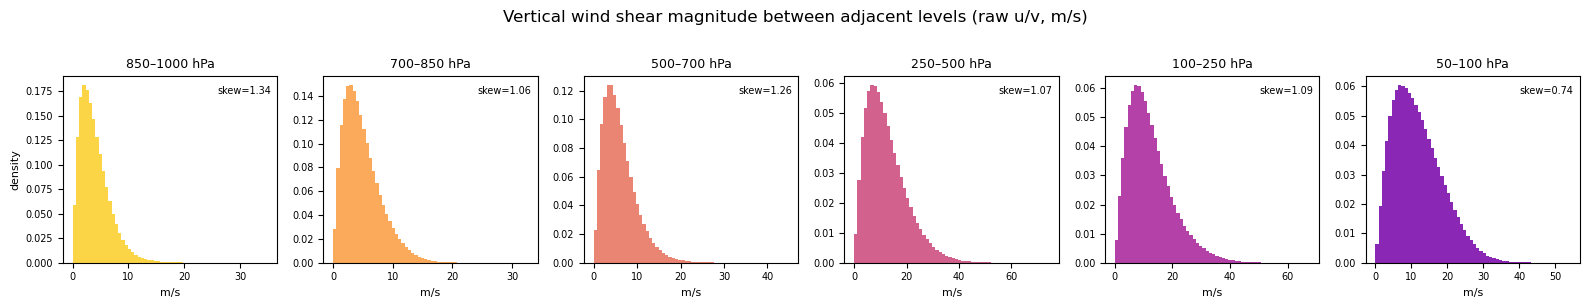

In [ ]:
# Vertical wind shear magnitude between adjacent levels (same formula as geounet)
# Computed from *raw* u/v here for physical interpretation
shear_levels = [(LEVELS[i + 1], LEVELS[i]) for i in range(N_LEVELS - 1)]
shear_labels = [f"{int(a)}–{int(b)}" for a, b in shear_levels]

shear = np.sqrt(
    (il[:, 2, 1:] - il[:, 2, :-1]) ** 2 + (il[:, 3, 1:] - il[:, 3, :-1]) ** 2
)  # (n_sample, 6, 64, 64)

fig, axes = plt.subplots(1, N_LEVELS - 1, figsize=(16, 3))
for li, (ax, label) in enumerate(zip(axes, shear_labels)):
    vals = shear[:, li].ravel()
    ax.hist(vals, bins=60, color=COLORS[li], alpha=0.85, density=True)
    ax.set_title(f"{label} hPa", fontsize=9)
    ax.set_xlabel("m/s", fontsize=8)
    ax.tick_params(labelsize=7)
    sk = float(scipy_stats.skew(vals))
    ax.text(
        0.97,
        0.95,
        f"skew={sk:.2f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=7,
    )
axes[0].set_ylabel("density", fontsize=8)
fig.suptitle(
    "Vertical wind shear magnitude between adjacent levels (raw u/v, m/s)",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()